<a href="https://colab.research.google.com/github/jtuchinsky/MathForML/blob/main/Monte_Carlo_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Setup:**
**Types of Supply:**
*   **Supply Type 1** (𝑆<sub>1</sub>): Can only fulfill **Demand Type 1** (D<sub>1</sub>).
*   **Supply Type 2** (S<sub>2</sub>): Can fulfill both **Demand Type 1** (D<sub>1</sub>) and **Demand Type 2** (D<sub>2</sub>).

**Types of Demand:**

*   D<sub>1</sub> and D<sub>2</sub>, both random variables with known probability distributions.

**Cost Structure:**

*   **Holding Cost** (H<sub>1</sub>, H<sub>2</sub>): Per unit of S<sub>1</sub> or S<sub>2</sub> left unsold.

*   **Stockout Cost** (C<sub>1</sub>, C<sub>2</sub>): Per unit of D<sub>1</sub> or D<sub>2</sub> unmet.



**Objective:** Minimize the **total expected cost** while ensuring:

*   S<sub>1</sub> is only used for D<sub>1</sub>.
*   S<sub>2</sub> is used for D<sub>1</sub> only if S<sub>1</sub> is insufficient, and to fulfill D<sub>2</sub>.

## Adjustments for Dependency:
1. Modeling Dependency:
If D<sub>1</sub> and D<sub>2</sub> are correlated, their joint behavior can be captured using a **bivariate normal distribution**:

$$  
\begin{bmatrix}D_{1}\\ D_{2}\end{bmatrix} \sim N\left(\begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix}, \begin{bmatrix} \sigma_1^2 & \rho \sigma_1 \sigma_2 \\ \rho \sigma_1 \sigma_2 & \sigma_2^2 \end{bmatrix}\right)  
$$  
Here:

$𝜇_1, 𝜇_2$: Means of $D_1$ and $D_2$.

$𝜎_1, 𝜎_2$: Standard deviations of $D_1$ and $D_2$.
𝜌: Correlation coefficient (−1 ≤ 𝜌 ≤ 1).

2. Sampling Dependent Demands:

Use the **Cholesky decomposition** of the covariance matrix to generate correlated random samples for $D_1$ and $D_2$.


### Adjustments for Lead Time:

#### 1. Define Lead Time:
Let L be the lead time (in weeks, days, etc.). The inventory decisions now consider:

- The **demand during lead time**, which adds uncertainty.
- The **replenishment cycle**, where orders are placed based on the expected lead time demand.

#### 2. Demand During Lead Time:
Let $D_L$ represent the total demand during the lead time L. If daily demand follows:  
$$D_1 \sim N(\mu_1, \sigma_1)\space and \space D_2 \sim N(\mu_2, \sigma_2)$$  
then:  
$$
D_{L_1} \sim N(L \cdot \mu_1, \sqrt{L} \cdot \sigma_1), \quad D_{L_2} \sim N(L \cdot \mu_2, \sqrt{L} \cdot \sigma_2)
$$

##### 3. Correlated Demand:
If $D_1 and \space D_2$ are correlated (correlation coefficient \( \rho \)), the joint lead time demand follows a multivariate normal distribution:
$$
D_L =
\begin{bmatrix}
D_{L_1} \\
D_{L_2}
\end{bmatrix}
\sim
N\left(
\begin{bmatrix}
L \cdot \mu_1 \\
L \cdot \mu_2
\end{bmatrix},
L \cdot
\begin{bmatrix}
\sigma_1^2 & \rho \cdot \sigma_1 \cdot \sigma_2 \\
\rho \cdot \sigma_1 \cdot \sigma_2 & \sigma_2^2
\end{bmatrix}
\right)
$$

#### 4. Inventory Policy:
Incorporate a reorder point R that ensures enough inventory to meet demand during lead time:
$$
R = \mu_L + z \cdot \sigma_L
$$
where:

- $\mu_L$: Mean lead time demand.
- $\sigma_L$: Standard deviation of lead time demand.
- $z$: Safety factor for the desired service level (e.g., $z = 1.645$ for 95%).

=== Optimization Results ===
Optimal Inventory Level for S1: 320
Optimal Inventory Level for S2: 200
Minimum Average Total Cost: $246.17


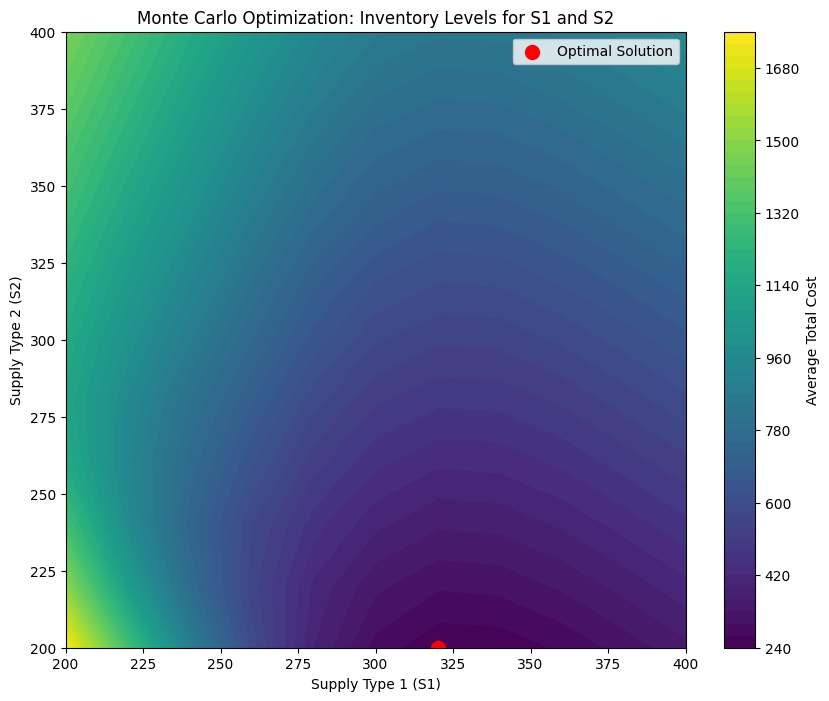

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mean_d1, std_d1 = 100, 20  # Daily Demand Type 1
mean_d2, std_d2 = 50, 10   # Daily Demand Type 2
rho = -0.5                  # Correlation between demands
L = 3                      # Lead time (days or weeks)
H_1, H_2 = 2, 3            # Holding costs for Supply 1 and Supply 2
C_1, C_2 = 10, 15          # Stockout costs for Demand 1 and Demand 2
z = 1.645                  # Safety factor for 95% service level
simulations = 10000        # Monte Carlo simulations
S1_range = range(200, 401, 20)  # Search range for Supply Type 1
S2_range = range(200, 401, 20)  # Search range for Supply Type 2

# Mean and covariance for joint lead time demand
mean_dL = np.array([L * mean_d1, L * mean_d2])
cov_matrix = L * np.array([[std_d1**2, rho * std_d1 * std_d2],
                           [rho * std_d1 * std_d2, std_d2**2]])
L_decomp = np.linalg.cholesky(cov_matrix)  # Cholesky decomposition

# Monte Carlo simulation
def simulate_cost(S1, S2):
    total_costs = []
    for _ in range(simulations):
        z = np.random.normal(0, 1, 2)
        demand = mean_dL + L_decomp @ z
        D1, D2 = max(0, demand[0]), max(0, demand[1])  # Ensure non-negative demand

        # Fulfill demand
        leftover_s1 = max(0, S1 - D1)
        unmet_d1 = max(0, D1 - S1)

        leftover_s2 = max(0, S2 - (unmet_d1 + D2))
        unmet_d2 = max(0, D2 - (S2 - unmet_d1))

        # Calculate costs
        holding_cost = H_1 * leftover_s1 + H_2 * leftover_s2
        stockout_cost = C_1 * unmet_d1 + C_2 * unmet_d2
        total_cost = holding_cost + stockout_cost
        total_costs.append(total_cost)
    return np.mean(total_costs)

# Optimization over S1 and S2 ranges
results = []
for S1 in S1_range:
    for S2 in S2_range:
        avg_cost = simulate_cost(S1, S2)
        results.append((S1, S2, avg_cost))

# Find the optimal combination
optimal_S1, optimal_S2, optimal_cost = min(results, key=lambda x: x[2])

# Results
print("=== Optimization Results ===")
print(f"Optimal Inventory Level for S1: {optimal_S1}")
print(f"Optimal Inventory Level for S2: {optimal_S2}")
print(f"Minimum Average Total Cost: ${optimal_cost:.2f}")

# Visualization
S1_vals, S2_vals, costs = zip(*results)
S1_vals = np.array(S1_vals).reshape(len(S1_range), len(S2_range))
S2_vals = np.array(S2_vals).reshape(len(S1_range), len(S2_range))
costs = np.array(costs).reshape(len(S1_range), len(S2_range))

plt.figure(figsize=(10, 8))
contour = plt.contourf(S1_vals, S2_vals, costs, levels=50, cmap='viridis')
plt.colorbar(contour, label='Average Total Cost')
plt.scatter(optimal_S1, optimal_S2, color='red', label='Optimal Solution', s=100)
plt.xlabel('Supply Type 1 (S1)')
plt.ylabel('Supply Type 2 (S2)')
plt.title('Monte Carlo Optimization: Inventory Levels for S1 and S2')
plt.legend()
plt.show()
